<a href="https://colab.research.google.com/github/keil4ni/151r-proj/blob/casey/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("short_video_engagement.csv")
print(df.head())

   views  likes  comments  watch_duration  shares  title_length  \
0     47     11         4       74.340181       0            18   
1     55     14         2       86.547617       1            89   
2     42      8         1       54.707006       0            97   
3     52     11         3       79.213670       1            73   
4     58      5         3       48.211898       0            62   

   description_length  edge_intensity  color_histogram  spectral_entropy  \
0                 878        0.436661         0.676880          0.524134   
1                  46        0.269328         0.376931          0.519303   
2                 568        0.136938         0.810070          0.636209   
3                 430        0.376898         0.873595          0.428849   
4                 339        0.380682         0.357269          0.580513   

   audio_intensity  engagement_score  
0         0.224402                 1  
1         0.044861                 1  
2         0.369313     

In [4]:
df

,views,likes,comments,watch_duration,shares,title_length,description_length,edge_intensity,color_histogram,spectral_entropy,audio_intensity,engagement_score
0,47,11,4,74.340181,0,18,878,0.436661,0.676880,0.524134,0.224402,1
1,55,14,2,86.547617,1,89,46,0.269328,0.376931,0.519303,0.044861,1
2,42,8,1,54.707006,0,97,568,0.136938,0.810070,0.636209,0.369313,1
3,52,11,3,79.213670,1,73,430,0.376898,0.873595,0.428849,0.220346,1
4,58,5,3,48.211898,0,62,339,0.380682,0.357269,0.580513,0.350787,0
...,...,...,...,...,...,...,...,...,...,...,...,...
17649,57,5,1,68.681723,0,81,536,0.015509,0.678075,0.727737,0.582059,0
17650,59,16,2,39.623208,2,50,659,0.434292,0.584963,0.421625,0.250497,1
17651,65,11,2,100.000000,0,69,422,0.678723,0.900423,0.653774,0.730677,0
17652,56,7,2,55.294093,0,39,325,0.045493,0.354416,0.479303,0.746592,0


In [6]:
df.columns

Index(['views', 'likes', 'comments', 'watch_duration', 'shares',
       'title_length', 'description_length', 'edge_intensity',
       'color_histogram', 'spectral_entropy', 'audio_intensity',
       'engagement_score'],
      dtype='object')

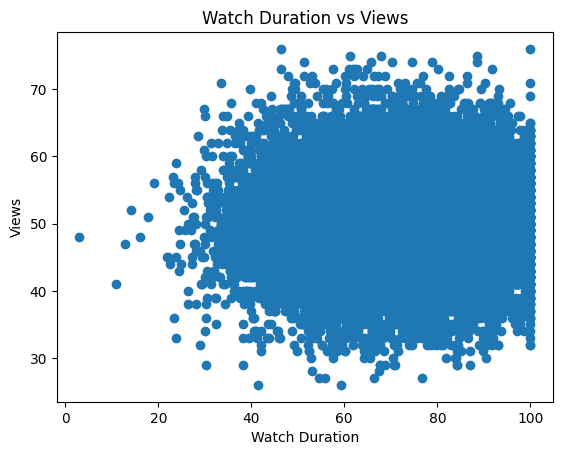

In [8]:
plt.scatter(df['watch_duration'], df['views'])
plt.xlabel('Watch Duration')
plt.ylabel('Views')
plt.title('Watch Duration vs Views')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[['watch_duration']]
y = df['views']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 0.0008399551166852902
Intercept: 49.901132183202385


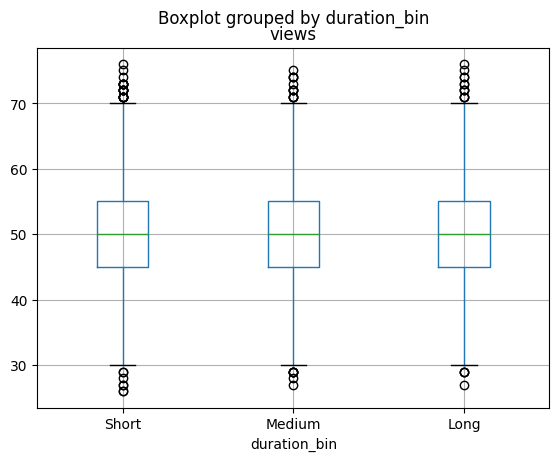

In [14]:
df['duration_bin'] = pd.qcut(
    df['watch_duration'],
    q=3,
    labels=['Short', 'Medium', 'Long']
)

df.boxplot(column='views', by='duration_bin')
plt.show()


In [15]:
df['duration_bin'] = pd.cut(
    df['watch_duration'],
    bins=[0, 60, 90, float('inf')],
    labels=['Short (≤60s)', 'Medium (60–90s)', 'Long (>90s)'],
    right=True
)

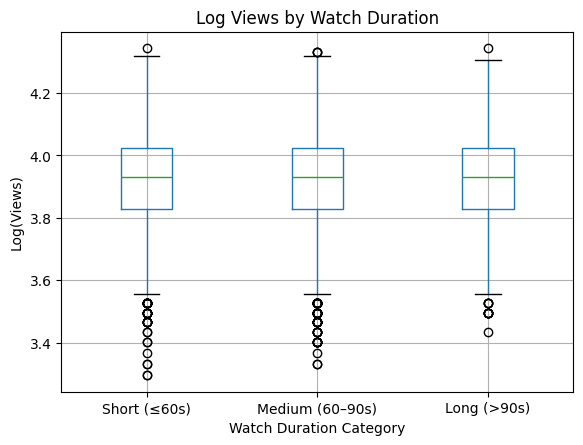

In [16]:
import numpy as np
import matplotlib.pyplot as plt

df['log_views'] = np.log1p(df['views'])

df.boxplot(column='log_views', by='duration_bin')
plt.xlabel('Watch Duration Category')
plt.ylabel('Log(Views)')
plt.title('Log Views by Watch Duration')
plt.suptitle('')
plt.show()


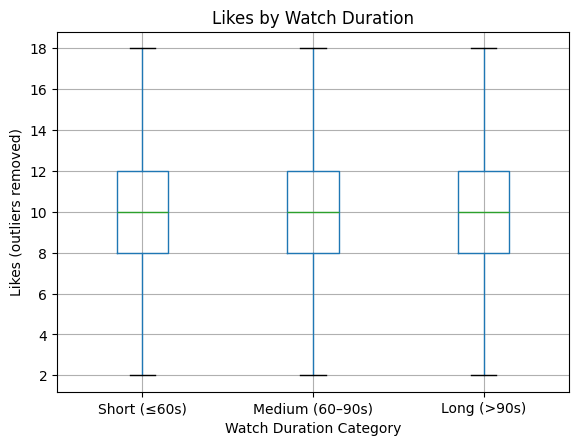

In [18]:
import numpy as np
import matplotlib.pyplot as plt

df['log_likes'] = np.log1p(df['likes'])

df.boxplot(
    column='likes',
    by='duration_bin',
    showfliers=False
)
plt.xlabel('Watch Duration Category')
plt.ylabel('Likes (outliers removed)')
plt.title('Likes by Watch Duration')
plt.suptitle('')
plt.show()


#Trying a new csv for youtube only

In [21]:
youtube = pd.read_csv("youtube_data.csv")
print(youtube.head())

      video_id                                              title  \
0  gsJAlLOFBv0                      TINY Tech That Actually Works   
1  ypicIkaiViM  AI & future of workforce: Andrew Yang on how t...   
2  1Nef8LPO-jo       5 ILLEGAL gadgets that will get you ARRESTED   
3  lCHqmzynO-s                      Overrated vs. Underrated Tech   
4  7uFrtqSwYzM  APPLE Glass Revolutionizes AR Experience Forever!   

                                         description        published_date  \
0                           No description available  2025-05-02T17:37:10Z   
1  Andrew Yang, Forward Party co-chair and former...  2025-06-18T12:39:53Z   
2  #shorts #technology \n\nI spend a LOT of time ...  2022-11-01T11:00:06Z   
3  💬 Join my Discord server: https://discord.gg/g...  2024-07-08T18:04:31Z   
4  Discover the revolutionary world of augmented ...  2024-12-22T16:49:00Z   

                 channel_id    channel_title  \
0  UCMiJRAwDNSNzuYeN2uWa0pA   Mrwhosetheboss   
1  UCrp_UI8XtuYfpiql

In [20]:
youtube.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail'],
      dtype='object')

In [24]:
import re

def youtube_duration_to_seconds(duration):
    if pd.isna(duration):
        return None

    hours = minutes = seconds = 0

    h = re.search(r'(\d+)H', duration)
    m = re.search(r'(\d+)M', duration)
    s = re.search(r'(\d+)S', duration)

    if h:
        hours = int(h.group(1))
    if m:
        minutes = int(m.group(1))
    if s:
        seconds = int(s.group(1))

    return hours * 3600 + minutes * 60 + seconds


youtube['duration_seconds'] = youtube['duration'].apply(youtube_duration_to_seconds)


In [26]:
youtube['duration_bin'] = pd.cut(
    youtube['duration_seconds'],
    bins=[0, 60, 90, float('inf')],
    labels=['Short (≤60s)', 'Medium (60–90s)', 'Long (>90s)']
)


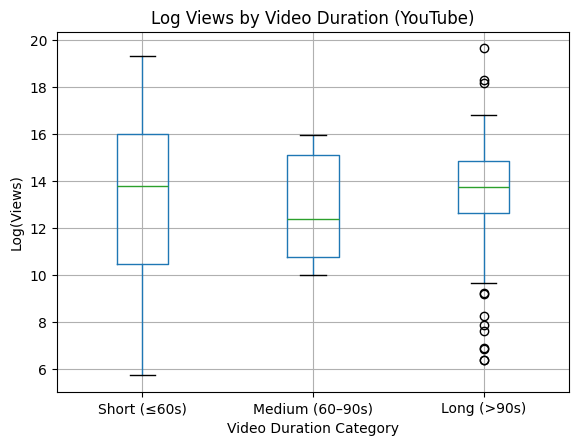

In [27]:
youtube['log_views'] = np.log1p(youtube['view_count'])

youtube.boxplot(column='log_views', by='duration_bin')
plt.xlabel('Video Duration Category')
plt.ylabel('Log(Views)')
plt.title('Log Views by Video Duration (YouTube)')
plt.suptitle('')
plt.show()

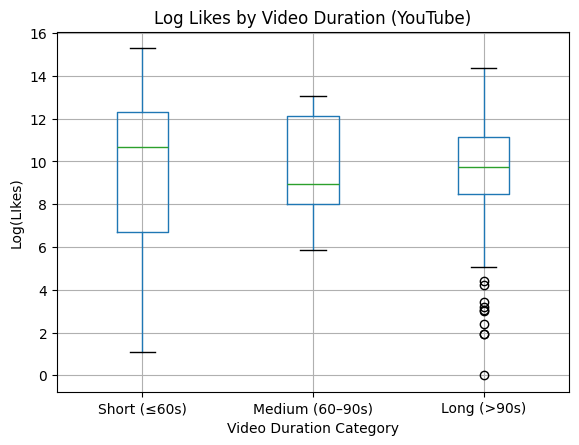

In [30]:
youtube['log_like'] = np.log1p(youtube['like_count'])

youtube.boxplot(column='log_like', by='duration_bin')
plt.xlabel('Video Duration Category')
plt.ylabel('Log(LIkes)')
plt.title('Log Likes by Video Duration (YouTube)')
plt.suptitle('')
plt.show()

In [37]:
youtube['engagement_rate'] = youtube['like_count'] / youtube['view_count']
youtube.groupby('duration_bin')['engagement_rate'].median()

/tmp/ipython-input-2159782979.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  youtube.groupby('duration_bin')['engagement_rate'].median()


,engagement_rate
duration_bin,
Short (≤60s),0.020778
Medium (60–90s),0.055434
Long (>90s),0.021907


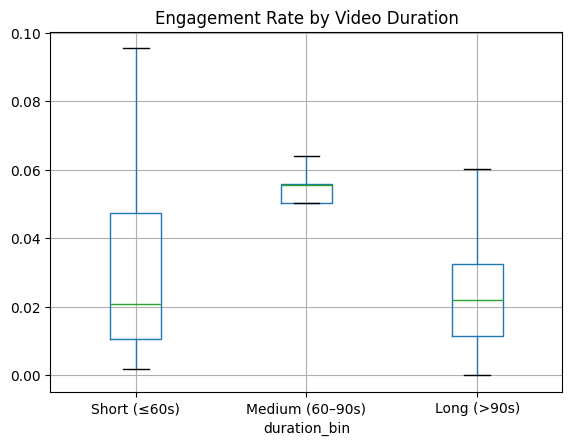

In [39]:
youtube.boxplot(column='engagement_rate', by='duration_bin', showfliers=False)
plt.title('Engagement Rate by Video Duration')
plt.suptitle('')
plt.show()


Medium-length videos (60–90s) have ~2.5× higher engagement than both Shorts and long videos

Shorts get views, but viewers are less likely to like

#Looking at the Tiktok Data

In [43]:
tiktok = pd.read_csv("tiktok_dataset.csv")
print(tiktok.head())

   # claim_status    video_id  video_duration_sec  \
0  1        claim  7017666017                  59   
1  2        claim  4014381136                  32   
2  3        claim  9859838091                  31   
3  4        claim  1866847991                  25   
4  5        claim  7105231098                  19   

                            video_transcription_text verified_status  \
0  someone shared with me that drone deliveries a...    not verified   
1  someone shared with me that there are more mic...    not verified   
2  someone shared with me that american industria...    not verified   
3  someone shared with me that the metro of st. p...    not verified   
4  someone shared with me that the number of busi...    not verified   

  author_ban_status  video_view_count  video_like_count  video_share_count  \
0      under review          343296.0           19425.0              241.0   
1            active          140877.0           77355.0            19034.0   
2            a

In [46]:
tiktok['engagement_rate'] = (
    tiktok['video_like_count'] / tiktok['video_view_count']
)

tiktok['duration_bin'] = pd.cut(
    tiktok['video_duration_sec'],
    bins=[0, 15, 30, 60, float('inf')],
    labels=['≤15s', '15–30s', '30–60s', '>60s']
)


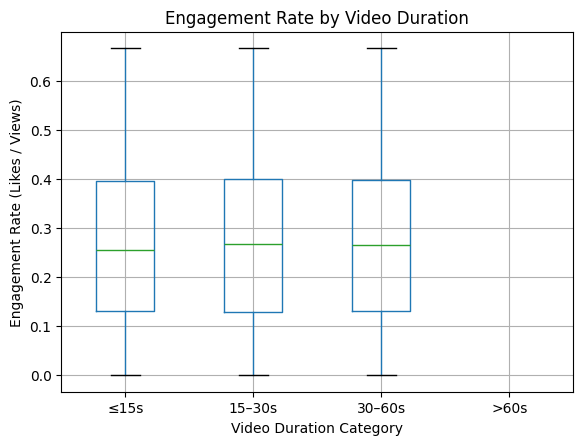

In [47]:
tiktok.boxplot(
    column='engagement_rate',
    by='duration_bin',
    showfliers=False
)

plt.xlabel('Video Duration Category')
plt.ylabel('Engagement Rate (Likes / Views)')
plt.title('Engagement Rate by Video Duration')
plt.suptitle('')
plt.show()


about the same engagment rate


In [50]:
tiktok['duration_bin'] = pd.cut(
    tiktok['video_duration_sec'],
    bins=[0, 15, 30, 60, float('inf')],
    labels=['≤15s', '15–30s', '30–60s', '>60s']
)

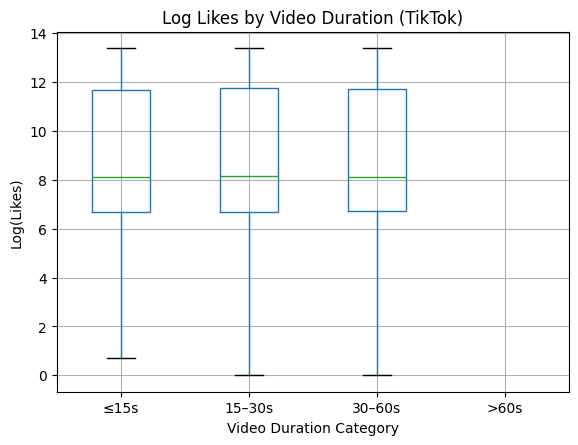

In [54]:
# log
tiktok['log_likes'] = np.log1p(tiktok['video_like_count'])

tiktok.boxplot(
    column='log_likes',
    by='duration_bin',
    showfliers=False
)

plt.xlabel('Video Duration Category')
plt.ylabel('Log(Likes)')
plt.title('Log Likes by Video Duration (TikTok)')
plt.suptitle('')
plt.show()


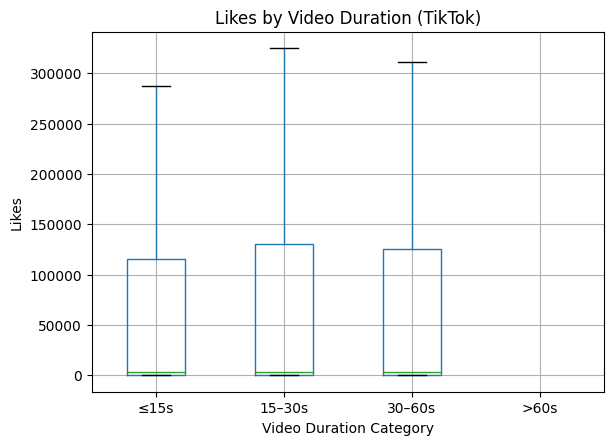

In [53]:
#raw
tiktok.boxplot(
    column='video_like_count',
    by='duration_bin',
    showfliers=False
)

plt.xlabel('Video Duration Category')
plt.ylabel('Likes')
plt.title('Likes by Video Duration (TikTok)')
plt.suptitle('')
plt.show()


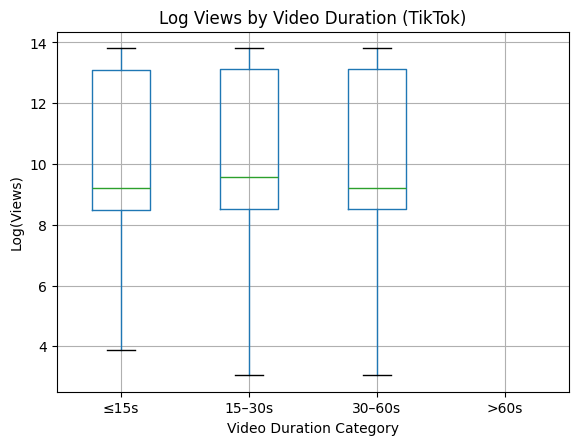

In [55]:
# log
tiktok['log_views'] = np.log1p(tiktok['video_view_count'])

tiktok.boxplot(
    column='log_views',
    by='duration_bin',
    showfliers=False
)

plt.xlabel('Video Duration Category')
plt.ylabel('Log(Views)')
plt.title('Log Views by Video Duration (TikTok)')
plt.suptitle('')
plt.show()


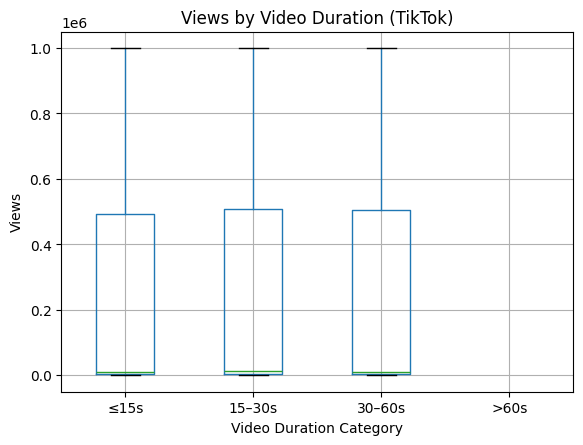

In [56]:
#raw
tiktok.boxplot(
    column='video_view_count',
    by='duration_bin',
    showfliers=False
)

plt.xlabel('Video Duration Category')
plt.ylabel('Views')
plt.title('Views by Video Duration (TikTok)')
plt.suptitle('')
plt.show()
